In [1]:
!pip install onnxruntime
!pip install onnxscript
!pip install transformers
!pip install datasets
!pip install timm  # Hugging Face uses this for many vision models
!pip install torch torchvision torchaudio
!pip install --upgrade torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 693.4/693.4 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 137.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.1/133.1 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 824.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 78.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [2]:
from google.colab import drive

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
import cv2
import matplotlib.pyplot as plt

In [5]:
# source_dir="/content/drive/MyDrive/Colab Notebooks/braintumour/brisc2025"
import glob
import random
from sklearn.model_selection import train_test_split

DATASET_DIR="/content/drive/MyDrive/Colab Notebooks/braintumour/brisc2025"

image_paths = glob.glob(DATASET_DIR + "/**/*.jpg", recursive=True)

train_paths, temp_paths = train_test_split(image_paths, test_size=0.2, stratify=None, random_state=42)
val_paths, test_paths = train_test_split(temp_paths, test_size=0.5, random_state=42)

print(len(train_paths), len(val_paths), len(test_paths))

4800 600 600


In [6]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


In [7]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),

    transforms.ToTensor(),


])


In [8]:

test_val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),


])


In [10]:
from torch.utils.data import Dataset
from PIL import Image
import os

class PathDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths = paths
        self.transform = transform
        self.class_to_idx = {"glioma":0, "meningioma":1, "pituitary":2, "no_tumor":3}

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        label_name = os.path.basename(os.path.dirname(path))
        label = self.class_to_idx[label_name]

        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        return image, label


In [12]:
train_dataset = PathDataset(train_paths, train_transforms)
val_dataset   = PathDataset(val_paths, test_val_transforms)
test_dataset  = PathDataset(test_paths, test_val_transforms)




In [13]:
batch_size = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

validation_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)


# ResNet 50

In [14]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load ResNet18 (smaller, faster)
model = models.resnet50(pretrained=True)

# Replace final layer for 4 classes
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 4)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 191MB/s]


In [16]:
import torch
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
    #weight_decay=1e-4   # L2 regularization
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.1
)


In [17]:
images, labels = next(iter(train_loader))
print(images.shape)   # [8, 3, 224, 224]
print(labels.shape)   # [8]
print(labels)


torch.Size([8, 3, 224, 224])
torch.Size([8])
tensor([1, 2, 2, 2, 2, 2, 2, 0])


In [18]:
from tqdm import tqdm

num_epochs = 8

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):

    ################
    # TRAIN
    ################
    model.train()
    running_train_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        # --- per-iteration (batch) loss ---
        batch_loss = loss.item()
        running_train_loss += batch_loss

        # show in tqdm progress bar
        pbar.set_postfix(batch_loss=f"{batch_loss:.4f}")

        # accuracy updates
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_train_loss = running_train_loss / len(train_loader)
    train_acc = correct / total


    ################
    # VALIDATION
    ################
    model.eval()
    running_val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in validation_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_val_loss = running_val_loss / len(validation_loader)
    val_acc = correct / total

    scheduler.step()

    # store history
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"\n📌 Epoch [{epoch+1}/{num_epochs}]")
    print(f"   🟢 Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"   🔵 Val   Loss: {avg_val_loss:.4f} | Val   Acc: {val_acc:.4f}")


Epoch 1/8: 100%|██████████| 600/600 [27:10<00:00,  2.72s/it, batch_loss=0.1869]



📌 Epoch [1/8]
   🟢 Train Loss: 0.3320 | Train Acc: 0.8806
   🔵 Val   Loss: 0.3469 | Val   Acc: 0.8700


Epoch 2/8: 100%|██████████| 600/600 [01:34<00:00,  6.36it/s, batch_loss=0.0569]



📌 Epoch [2/8]
   🟢 Train Loss: 0.1546 | Train Acc: 0.9481
   🔵 Val   Loss: 0.0931 | Val   Acc: 0.9733


Epoch 3/8: 100%|██████████| 600/600 [01:33<00:00,  6.40it/s, batch_loss=0.0149]


...


📌 Epoch [6/8]
   🟢 Train Loss: 0.0287 | Train Acc: 0.9917
   🔵 Val   Loss: 0.0388 | Val   Acc: 0.9867


Epoch 7/8: 100%|██████████| 600/600 [01:33<00:00,  6.41it/s, batch_loss=0.0004]



📌 Epoch [7/8]
   🟢 Train Loss: 0.0177 | Train Acc: 0.9956
   🔵 Val   Loss: 0.0340 | Val   Acc: 0.9883


Epoch 8/8: 100%|██████████| 600/600 [01:33<00:00,  6.42it/s, batch_loss=0.0009]



📌 Epoch [8/8]
   🟢 Train Loss: 0.0102 | Train Acc: 0.9977
   🔵 Val   Loss: 0.0320 | Val   Acc: 0.9883


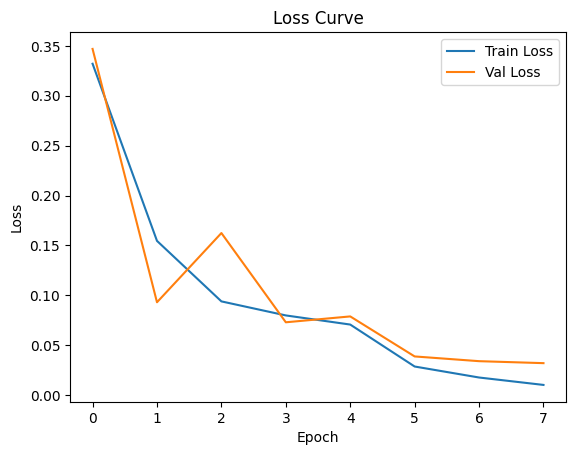

In [20]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.show()


In [21]:
model.eval()
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

test_accuracy = correct / total
print(f"Test Accuracy: {test_accuracy:.4f}")


Test Accuracy: 0.9883


In [22]:
model.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [23]:
import onnxruntime as ort
import torch
import torch.onnx
import onnx
import onnxruntime as ort
import numpy as np

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [25]:
dummy_input = torch.randn(1, 3, 224, 224).to(device)

In [26]:
onnx_path="Resnet50_brain_tumour_classifier.onnx"
torch.onnx.export(
    model,
    dummy_input,
    onnx_path,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={
        "input": {0: "batch_size"},
        "output": {0: "batch_size"}
    },
    export_params=True,
    opset_version=18,
)

/tmp/ipython-input-3938807188.py:2: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 106 of general pattern rewrite rules.


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 18},
            producer_name='pytorch',
            producer_version='2.9.1+cu128',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[s77,3,224,224]>
            ),
            outputs=(
                %"output"<FLOAT,[1,4]>
            ),
            initializers=(
                %"conv1.weight"<FLOAT,[64,3,7,7]>{Tensor(...)},
                %"layer1.0.conv1.weight"<FLOAT,[64,64,1,1]>{Tensor(...)},
                %"layer1.0.conv2.weight"<FLOAT,[64,64,3,3]>{Tensor(...)},
                %"layer1.0.conv3.weight"<FLOAT,[256,64,1,1]>{Tensor(...)},
                %"layer1.0.downsample.0.weight"<FLOAT,[256,64,1,1]>{Tensor(...)},
                %"layer1.1.conv1.weight"<FLOAT,[64,256,1,1]>{Tensor(...)},
                %"layer1.1.conv2.weight"<FLOAT,[64,64,3,3]>{Tensor(...)},
      

# In case you are wondering  how to merge the .onnx and .onnx.data file together then you can just load them model and the onnx runtime automatically uses the .onnx.data file which mainly contains parameters will also be used through the model .onnx file.

In [27]:
modelLoaded= onnx.load("Resnet50_brain_tumour_classifier.onnx")
onnx.save(modelLoaded, "Resnet50_brain_tumour_classifier_merged.onnx",save_as_external_data=False)